In [1]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import multiprocessing as mp
import time
import numpy as np
import itertools
import tools21cm as t2c
from scipy import stats
from tqdm import tqdm
import astropy.units as u
import astropy.constants as cst

plt.rcParams["font.family"] = "serif"

from astropy.io import fits
import casacore.tables as ct

2024-06-13 15:56:09.137930: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## __Analyzing SKA .MS data.__

### Note: The file has only one frequency!

In [2]:
path= '/scratch/snx3000/vrajkovi/'
#ms_file = path + 'lc_256_train_130923_i0_dTgf_ch600_4h1d_256.MS'
#ms_file = path + 'syngf_ch600_1024_copy.MS'
ms_file = path + 'syngf_ch600_1024_60timesteps.MS'
ms = ct.table(ms_file, readonly=True, ack=False)

# Get the time and antenna1/antenna2 columns
times = ms.getcol('TIME')
ant1 = ms.getcol('ANTENNA1')
ant2 = ms.getcol('ANTENNA2')

# Get the unique antenna IDs and number of antennas
antennas = np.unique(np.concatenate((ant1, ant2)))
del ant1 , ant2

In [3]:
print(ms)

Table: /scratch/snx3000/vrajkovi/syngf_ch600_1024_60timesteps.MS
7848960 rows
22 columns: UVW FLAG FLAG_CATEGORY WEIGHT SIGMA ANTENNA1 ANTENNA2 ARRAY_ID DATA_DESC_ID EXPOSURE FEED1 FEED2 FIELD_ID FLAG_ROW INTERVAL OBSERVATION_ID PROCESSOR_ID SCAN_NUMBER STATE_ID TIME TIME_CENTROID DATA


In [4]:
spw_table = ct.table(ms.getkeyword('SPECTRAL_WINDOW'), readonly=True, ack=False)
print(spw_table)
freq = spw_table.getcol('CHAN_FREQ')
print(freq)

Table: /scratch/snx3000/vrajkovi/syngf_ch600_1024_60timesteps.MS/SPECTRAL_WINDOW
1 rows
14 columns: MEAS_FREQ_REF CHAN_FREQ REF_FREQUENCY CHAN_WIDTH EFFECTIVE_BW RESOLUTION FLAG_ROW FREQ_GROUP FREQ_GROUP_NAME IF_CONV_CHAIN NAME NET_SIDEBAND NUM_CHAN TOTAL_BANDWIDTH
[[1.66e+08]]


In [5]:
#Storing the antenna layout (x and y) coordinates
ant_table = ct.table(ms.getkeyword('ANTENNA'), readonly=True, ack=False)
print(ant_table)
ant_coords = ant_table.getcol('POSITION')
#np.save('SKA_material/SKA_ant_coords.npy', ant_coords[:,0:-1])

Table: /scratch/snx3000/vrajkovi/syngf_ch600_1024_60timesteps.MS/ANTENNA
512 rows
8 columns: OFFSET POSITION TYPE DISH_DIAMETER FLAG_ROW MOUNT NAME STATION


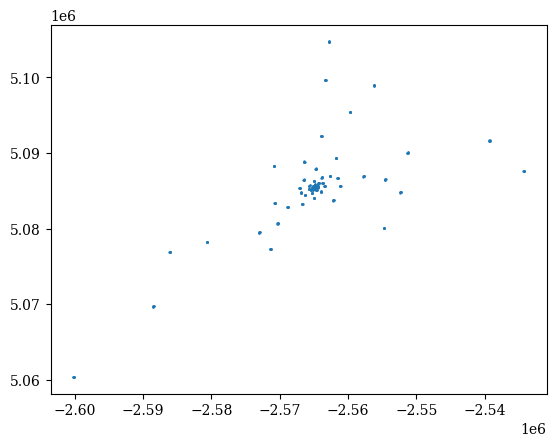

In [6]:
plt.scatter(ant_coords[:,0], ant_coords[:, 1], s=0.5)

In [9]:
# Get the UVW and Visibility data for all rows in the MS
uvw_data = ms.getcol('UVW')
vis_data = ms.getcol('DATA')

print(uvw_data[:,:2].shape)
print(vis_data[:,:,0].shape)

#np.save('../SKA_material/bl_syngf_ch600_1024_60timesteps.npy', uvw_data[:,:2])
#np.save('../SKA_material/vis_syngf_ch600_1024_60timesteps.npy', vis_data[:,:,0])

(7848960, 2)
(7848960, 1)


In [10]:
# Get the time and antenna1/antenna2 columns
times = ms.getcol('TIME')
ant1 = ms.getcol('ANTENNA1')
ant2 = ms.getcol('ANTENNA2')

# Get the unique antenna IDs and number of antennas
antennas = np.unique(np.concatenate((ant1, ant2)))
num_antennas = len(antennas)
print('Number of antennas: ', num_antennas)
num_baselines = int(num_antennas * (num_antennas - 1) / 2)
print("Number of baselines: ", num_baselines)
del ant1, ant2

num_times = len(np.unique(times))
print("Time steps: ", num_times)
del times

# Get the frequency data from the SPECTRAL_WINDOW subtable
spw_table = ct.table(ms.getkeyword('SPECTRAL_WINDOW'), readonly=True, ack=False)
frequency = spw_table.getcol('CHAN_FREQ')

print("vis_data raw shape: ", vis_data.shape)
print('Frequency: ', frequency)

Number of antennas:  512
Number of baselines:  130816
Time steps:  60
vis_data raw shape:  (7848960, 1, 4)
Frequency:  [[1.66e+08]]


## __Analyzing LOFAR data to extract the frequencies.__

In [2]:
path= '/scratch/snx3000/vrajkovi/LoTSS_DR2/L242820_SB230_uv.dppp.pre-cal_125145DD7t_166MHz.pre-cal.ms.archive'
ms_file = path
ms = ct.table(ms_file, readonly=True, ack=False)

In [3]:
print(ms)

Table: /scratch/snx3000/vrajkovi/LoTSS_DR2/L242820_SB230_uv.dppp.pre-cal_125145DD7t_166MHz.pre-cal.ms.archive
6798145 rows
25 columns: UVW FLAG_CATEGORY WEIGHT SIGMA ANTENNA1 ANTENNA2 ARRAY_ID DATA_DESC_ID EXPOSURE FEED1 FEED2 FIELD_ID FLAG_ROW INTERVAL OBSERVATION_ID PROCESSOR_ID SCAN_NUMBER STATE_ID TIME TIME_CENTROID DATA FLAG LOFAR_FULL_RES_FLAG WEIGHT_SPECTRUM IMAGING_WEIGHT


In [4]:
spw_table = ct.table(ms.getkeyword('SPECTRAL_WINDOW'), readonly=True, ack=False)
print(spw_table)

Table: /scratch/snx3000/vrajkovi/LoTSS_DR2/L242820_SB230_uv.dppp.pre-cal_125145DD7t_166MHz.pre-cal.ms.archive/SPECTRAL_WINDOW
1 rows
14 columns: MEAS_FREQ_REF REF_FREQUENCY FLAG_ROW FREQ_GROUP FREQ_GROUP_NAME IF_CONV_CHAIN NAME NET_SIDEBAND NUM_CHAN TOTAL_BANDWIDTH CHAN_FREQ CHAN_WIDTH EFFECTIVE_BW RESOLUTION


In [5]:
freq_list = spw_table.getcol('CHAN_FREQ')
num_freqs = len(freq_list[0])

print(freq_list.shape)
print(len(freq_list[0]))

#np.save('LOFAR_material/LOFAR_frequencies.npy', freq_list[0])

(1, 20)
20


In [6]:
uvw_data = ms.getcol('UVW')
vis_data = ms.getcol('DATA')
times = ms.getcol('TIME')
num_times = len(np.unique(times))

ant1 = ms.getcol('ANTENNA1')
ant2 = ms.getcol('ANTENNA2')
num_antennas = len(np.unique(np.concatenate((ant1, ant2))))
num_baselines = int(num_antennas * (num_antennas - 1) / 2)

print(uvw_data.shape)
print(vis_data.shape)
print(times.shape)
print(num_times)
print(num_baselines)

(6798145, 3)
(6798145, 20, 4)
(6798145,)
3595
1891


In [7]:
uvw_data_reshape = uvw_data.reshape(num_times, num_baselines, 3)
vis_data_reshape = vis_data.reshape(num_times, num_baselines, num_freqs, 4)

#np.save('LOFAR_material/LOFAR_baselines.npy', uvw_data_reshape[:,:,0:2])
#np.save('LOFAR_material/LOFAR_visibilities.npy', vis_data_reshape[:,:,:,0])

In [10]:
ant_field_table = ct.table(ms.getkeyword('LOFAR_ANTENNA_FIELD'), readonly=True, ack=False)
print(ant_field_table)

Table: /scratch/snx3000/vrajkovi/LoTSS_DR2/L242820_SB230_uv.dppp.pre-cal_125145DD7t_166MHz.pre-cal.ms.archive/LOFAR_ANTENNA_FIELD
62 rows
9 columns: ANTENNA_ID NAME POSITION COORDINATE_AXES ELEMENT_OFFSET ELEMENT_RCU ELEMENT_FLAG TILE_ROTATION TILE_ELEMENT_OFFSET


In [14]:
antenna_table = ct.table(ms.getkeyword('ANTENNA'), readonly=True, ack=False)
print(antenna_table)
dish_diameter = antenna_table.getcol('DISH_DIAMETER')
print(dish_diameter)

Table: /scratch/snx3000/vrajkovi/LoTSS_DR2/L242820_SB230_uv.dppp.pre-cal_125145DD7t_166MHz.pre-cal.ms.archive/ANTENNA
62 rows
10 columns: OFFSET POSITION TYPE DISH_DIAMETER FLAG_ROW MOUNT NAME STATION LOFAR_STATION_ID LOFAR_PHASE_REFERENCE
[31.26253314 31.26205363 31.26088262 31.26004498 31.2616083  31.26088262
 31.26119281 31.26107447 31.2609664  31.26052641 31.26157855 31.26088262
 31.26023199 31.26080197 31.26097683 31.26064371 31.26232237 31.26282011
 31.26092611 31.26146782 31.26129806 31.26121855 31.26065246 31.26101526
 31.26068628 31.26082363 31.26197662 31.26198829 31.26143517 31.26131056
 31.26158847 31.26158847 31.26197245 31.26214819 31.26020204 31.2609969
 31.26094994 31.26094571 31.26152727 31.26096827 31.26116818 31.26082166
 31.26097876 31.2619882  31.26439179 31.27042055 31.26060535 31.26182501
 31.26119281 31.25984819 31.26137624 31.26185895 31.26133704 31.26021683
 31.26107325 31.2605103  31.26026733 31.26170071 31.26166507 31.26072869
 31.2606945  31.26008302]


In [24]:
lofar_subtable = ct.table(ms.getkeyword('SPECTRAL_WINDOW'), readonly=True, ack=False)
print(lofar_subtable)
#print(lofar_subtable.getcol('LOFAR_TILE_BEAM_DIR'))

Table: /scratch/snx3000/vrajkovi/LoTSS_DR2/L242820_SB230_uv.dppp.pre-cal_125145DD7t_166MHz.pre-cal.ms.archive/SPECTRAL_WINDOW
1 rows
14 columns: MEAS_FREQ_REF REF_FREQUENCY FLAG_ROW FREQ_GROUP FREQ_GROUP_NAME IF_CONV_CHAIN NAME NET_SIDEBAND NUM_CHAN TOTAL_BANDWIDTH CHAN_FREQ CHAN_WIDTH EFFECTIVE_BW RESOLUTION
